## TC 5033
### Text Classifier with RNNs

<br>

### Nombres: Freddy Silva, César Cruz, Fernando Guevara, Kailin Wu
### Matrículas: A00828792, A00825747, A00828723, A00830574


#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [4]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install scipy==1.9.3
!pip install scikit-plot
#you may receive a message of restarting session, this is OK

  Using cached scipy-1.9.3.tar.gz (42.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [50 lines of output]
      + meson setup /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be/.mesonpy-wbpfs7e_ -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=/tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be/.mesonpy-wbpfs7e_/meson-python-native-file.ini
      The Meson build system
      Version: 1.10.1
      Source dir: /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be
      Build dir: /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be/.mesonpy-wbpfs7e_
      Build type: native build
      Projec

In [6]:
!pip install portalocker
!pip install "numpy<2"
#please restar session after this intallation. After restarting go straight to importing the libraries


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Import libraries

In [2]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
import scipy
scipy.interp = np.interp
import scikitplot as skplt
import gc

In [3]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

We convert to Map-style so we could use indices and random_split

In [4]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

We use *basic_english* for text normalizing. (Lowercasing, punctuation, etc). And create *yield_tokens* to process text word by word.

In [5]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

In [6]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [7]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


To avoid overfitting, 10% of train data is separated for validation.

In [8]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [9]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [10]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


Function *collate_batch* transforms list in tensors.

In [11]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [12]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

Finally, creating the loaders that will feed the model in batches of 256 news.

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [14]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

In [15]:
import torch.nn as nn

class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        # Capa de Embedding: convierte índices en vectores densos
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), 
                                            embedding_dim=embed_size)

        # Usaremos GRU por su buen balance entre velocidad y memoria
        # batch_first=True indica que la entrada será [Batch, Seq_Len, Features]
        self.rnn = nn.GRU(input_size=embed_size, 
                          hidden_size=hidden, 
                          num_layers=layers, 
                          batch_first=True)

        # Capa de salida: clasificador lineal que mapea de neuronas ocultas a clases
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x):
        # 1. Pasar por el embedding: [batch, 50] -> [batch, 50, 300]
        embedded = self.embedding_layer(x)
        
        # 2. Pasar por la GRU. 
        # rnn_out contiene la salida de cada paso de tiempo
        # hidden contiene el estado final de las capas
        rnn_out, hidden = self.rnn(embedded)
        
        # 3. Tomamos solo el último estado oculto (last time step)
        # rnn_out[:, -1, :] selecciona el último vector de la secuencia
        last_time_step = rnn_out[:, -1, :]
        
        # 4. Clasificación final
        logits = self.fc(last_time_step)
        
        return logits

# Instanciar el modelo con tus variables
model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)

In [16]:
def accuracy(model, loader):
    # 1. Ponemos el modelo en modo evaluación (desactiva Dropout, etc.)
    model.eval()
    
    correct = 0
    total = 0
    
    # 2. Desactivamos el cálculo de gradientes para ahorrar memoria y velocidad
    with torch.no_grad():
        for x, y in loader:
            # Asegurarnos de que los datos estén en el mismo dispositivo que el modelo (CPU o GPU)
            x = x.to(device=next(model.parameters()).device)
            y = y.to(device=next(model.parameters()).device)
            
            # 3. Obtenemos las predicciones (logits)
            logits = model(x)
            
            # 4. Encontramos el índice de la clase con el valor más alto (predicción)
            # dim=1 porque buscamos el máximo en las columnas de las clases
            _, preds = torch.max(logits, dim=1)
            
            # 5. Contamos cuántas fueron correctas
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    # Retornamos el porcentaje de precisión
    return correct / total

In [17]:
def train(model, optimiser, epochs=100):
    # 1. Definir la función de pérdida (Criterio)
    # CrossEntropy ya incluye la activación Softmax internamente
    loss_function = nn.CrossEntropyLoss()
    
    # Aseguramos que el modelo esté en el dispositivo correcto (GPU/CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"Entrenando en: {device}")

    for epoch in range(epochs):
        model.train() # Modo entrenamiento
        total_loss = 0
        
        for x, y in train_loader:
            # Mover datos al dispositivo
            x = x.to(device)
            y = y.to(device).long() # Las etiquetas deben ser long para CrossEntropy
            
            # --- El "Triple Paso" de PyTorch ---
            # A. Limpiar gradientes anteriores
            optimiser.zero_grad()
            
            # B. Forward: Pasar datos por el modelo
            logits = model(x)
            loss = loss_function(logits, y)
            
            # C. Backward: Calcular gradientes y actualizar pesos
            loss.backward()
            optimiser.step()
            
            total_loss += loss.item()
        
        # 2. Evaluación al final de cada época
        # Usamos la función accuracy que definimos antes
        train_acc = accuracy(model, train_loader)
        val_acc = accuracy(model, val_loader)
        
        print(f'Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | '
              f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

In [18]:
# Un valor de 10 a 20 épocas suele ser suficiente para AG_NEWS sin sobreentrenar
epochs = 10 

# Un learning rate de 0.001 es el "punto dulce" para el optimizador Adam
lr = 0.001 

# Instanciamos el modelo
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)

# Configuramos el optimizador (asegurándonos de usar rnn_model)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

# Llamamos a la función de entrenamiento
train(rnn_model, optimiser, epochs=epochs)

Entrenando en: cpu
Epoch 1/10 | Loss: 0.5423 | Train Acc: 0.9177 | Val Acc: 0.8945
Epoch 2/10 | Loss: 0.2272 | Train Acc: 0.9512 | Val Acc: 0.9133
Epoch 3/10 | Loss: 0.1535 | Train Acc: 0.9699 | Val Acc: 0.9150
Epoch 4/10 | Loss: 0.1000 | Train Acc: 0.9792 | Val Acc: 0.9122
Epoch 5/10 | Loss: 0.0632 | Train Acc: 0.9882 | Val Acc: 0.9119
Epoch 6/10 | Loss: 0.0439 | Train Acc: 0.9934 | Val Acc: 0.9125
Epoch 7/10 | Loss: 0.0285 | Train Acc: 0.9954 | Val Acc: 0.9111
Epoch 8/10 | Loss: 0.0211 | Train Acc: 0.9949 | Val Acc: 0.9087
Epoch 9/10 | Loss: 0.0193 | Train Acc: 0.9957 | Val Acc: 0.9096
Epoch 10/10 | Loss: 0.0164 | Train Acc: 0.9967 | Val Acc: 0.9075


In [19]:
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.9079


In [20]:
def sample_text(model, loader):
    # 1. Modo evaluación y mover al dispositivo correcto
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # Mapa inverso para el vocabulario (ID -> Palabra)
    # Esto nos permite reconstruir la oración que el modelo está leyendo
    itos = vocab.get_itos()
    
    # Tomamos un solo batch del cargador de datos
    x, y = next(iter(loader))
    
    with torch.no_grad():
        x, y = x.to(device), y.to(device)
        logits = model(x)
        _, preds = torch.max(logits, dim=1)
    
    # Mostramos los primeros 5 ejemplos del batch
    print(f"{'PREDICCIÓN':<15} | {'REAL':<15} | {'TEXTO (TRUNCADO)'}")
    print("-" * 80)
    
    for i in range(5):
        # Reconstruir el texto desde los índices (quitando los ceros del padding)
        text_indices = x[i].tolist()
        tokens = [itos[idx] for idx in text_indices if idx != 0] # 0 suele ser el padding
        sentence = " ".join(tokens[:10]) + "..." # Solo mostramos el inicio
        
        pred_label = labels[preds[i].item()]
        true_label = labels[y[i].item()]
        
        print(f"{pred_label:<15} | {true_label:<15} | {sentence}")

In [21]:
sample_text(rnn_model, test_loader)

PREDICCIÓN      | REAL            | TEXTO (TRUNCADO)
--------------------------------------------------------------------------------
Sports          | Sports          | wisdom was main course waltham -- he is an man...
World           | World           | soldiers face abu ghraib hearings four us soldiers charged with...
Sci/Tech        | Sci/Tech        | microsoft to launch new search engine software giant , microsoft...
Business        | Business        | observers insist no proof of fraud in venezuelan referendum ....
World           | World           | israeli army set to unveil stink bomb jerusalem the israeli...


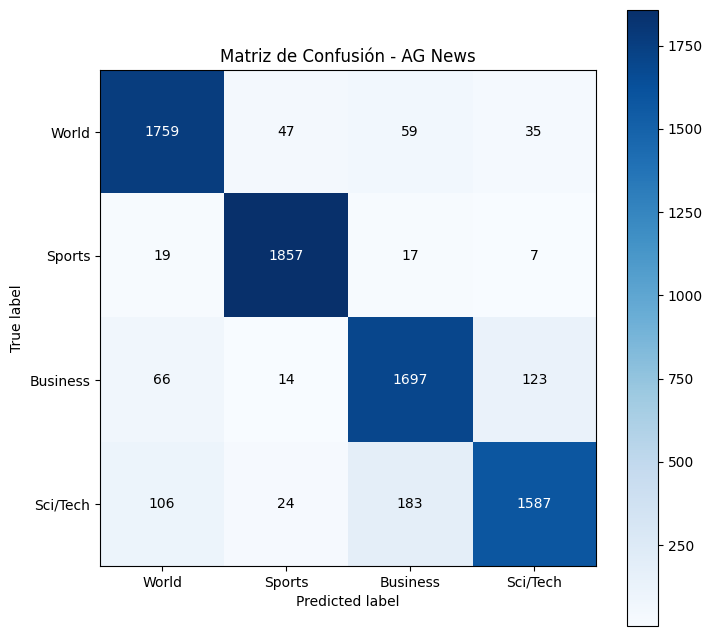

In [22]:
import matplotlib.pyplot as plt
import scikitplot as skplot

def plot_confusion_matrix(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            # Guardamos las etiquetas reales
            y_true.extend(y.numpy())
            
            # Obtenemos las predicciones del modelo
            logits = model(x)
            _, preds = torch.max(logits, dim=1)
            y_pred.extend(preds.cpu().numpy())
    
    # Graficamos usando scikitplot
    skplot.metrics.plot_confusion_matrix(y_true, y_pred, figsize=(8,8), title="Matriz de Confusión - AG News")
    
    # Ajustamos los nombres de las categorías en los ejes
    tick_marks = range(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    plt.show()

# Llamada a la función
plot_confusion_matrix(rnn_model, test_loader)